<a href="https://colab.research.google.com/github/Thinujan-Thillaiselvan/ME320/blob/main/E21411_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Derivation of the Equations of Motion

**Coordinate Systems & Kinematics**
Let the generalized coordinates be $q = [\theta, \phi, y]^T$.
* **Frame e:** Earth-fixed inertial frame, with $e_3$ pointing vertically upwards. Gravity acts in the $-e_3$ direction ($\vec{g} = -g e_3$).
* **Frame b:** Rotates with the disk assembly about the vertical axis $e_3$ by angle $\theta$. $\vec{\omega}_{b/e} = \dot{\theta} b_3$ where $b_3 = e_3$.
* **Frame c:** Fixed to the disk. The disk rotates (tilts) about the horizontal axis $b_1$ by angle $\phi$. $\vec{\omega}_{c/b} = \dot{\phi} c_1$ where $c_1 = b_1$.

The angular velocity of the disk (frame $c$) is:
$$\vec{\omega}_c = \dot{\theta} b_3 + \dot{\phi} c_1$$
Projecting $b_3$ into the $c$ frame using the rotation relation ($c_2 = \cos\phi b_2 + \sin\phi b_3$ and $c_3 = -\sin\phi b_2 + \cos\phi b_3$), we get $b_3 = \sin\phi c_2 + \cos\phi c_3$.
$$\vec{\omega}_c = \dot{\phi} c_1 + \dot{\theta}\sin\phi c_2 + \dot{\theta}\cos\phi c_3$$

**Position and Velocity of the Bead ($P$)**
From the diagram, the bead is offset by $-d$ along $c_2$ and its position along the slot is $y$ along $c_3$.
$$\vec{r}_P = -d c_2 + y c_3$$
The velocity of the bead is $\vec{v}_P = \frac{d}{dt}(\vec{r}_P) = \dot{y} c_3 + \vec{\omega}_c \times \vec{r}_P$. Computing the cross product yields:
$$\vec{v}_P = (y\dot{\theta}\sin\phi + d\dot{\theta}\cos\phi) c_1 - y\dot{\phi} c_2 + (\dot{y} - d\dot{\phi}) c_3$$
The squared velocity of the bead is:
$$v_P^2 = (y\sin\phi + d\cos\phi)^2 \dot{\theta}^2 + y^2 \dot{\phi}^2 + (\dot{y} - d\dot{\phi})^2$$

**Kinetic Energy ($T$)**
The total kinetic energy is $T = T_{\text{disk}} + T_{\text{bead}}$.
Let $I_{11}, I_{22}, I_{33}$ be the principal moments of inertia of the disk (with the slot removed) about the origin $O$ in frame $c$.
$$T = \frac{1}{2} \left[ I_{11} \dot{\phi}^2 + I_{22} (\dot{\theta}\sin\phi)^2 + I_{33} (\dot{\theta}\cos\phi)^2 \right] + \frac{1}{2} m \left[ (y\sin\phi + d\cos\phi)^2 \dot{\theta}^2 + y^2 \dot{\phi}^2 + (\dot{y} - d\dot{\phi})^2 \right]$$

**Potential Energy ($V$)**
Let $M_s$ be the mass of the material removed for the slot. Removing the slot shifts the center of mass of the disk along the positive $c_2$ axis to $\vec{r}_{cm} = \frac{M_s d}{M_D} c_2$, where $M_D$ is the net mass of the disk.
The vertical heights (along $b_3$) are:
* Bead: $z_P = \vec{r}_P \cdot b_3 = y\cos\phi - d\sin\phi$
* Disk CM: $z_{cm} = \vec{r}_{cm} \cdot b_3 = \frac{M_s d}{M_D} \sin\phi$

Total potential energy (Gravity + Spring):
$$V = m g (y\cos\phi - d\sin\phi) + M_s g d \sin\phi + \frac{1}{2} k y^2$$

**Euler-Lagrange Equations ($L = T - V$)**
Applying $\frac{d}{dt}(\frac{\partial L}{\partial \dot{q_i}}) - \frac{\partial L}{\partial q_i} = 0$:

**1. $\theta$-Equation:**
$$\frac{d}{dt} \left[ \left( I_{22} \sin^2\phi + I_{33} \cos^2\phi + m (y\sin\phi + d\cos\phi)^2 \right) \dot{\theta} \right] = 0$$
*(Note: Since $\theta$ is cyclic, angular momentum about the vertical axis is conserved).*

**2. $\phi$-Equation:**
$$(I_{11} + m(y^2 + d^2)) \ddot{\phi} - m d \ddot{y} + 2m y \dot{y} \dot{\phi} - (I_{22} - I_{33})\sin\phi\cos\phi \dot{\theta}^2 - m(y\sin\phi + d\cos\phi)(y\cos\phi - d\sin\phi)\dot{\theta}^2 + m g (y\sin\phi + d\cos\phi) - M_s g d \cos\phi = 0$$

**3. $y$-Equation:**
$$m(\ddot{y} - d\ddot{\phi}) - m \dot{\theta}^2 (y\sin\phi + d\cos\phi)\sin\phi - m y \dot{\phi}^2 + m g \cos\phi + k y = 0$$


# 2. Simulation and Plots
Run the cell below to numerically integrate the nonlinear coupled equations of motion and visualize the dynamics.

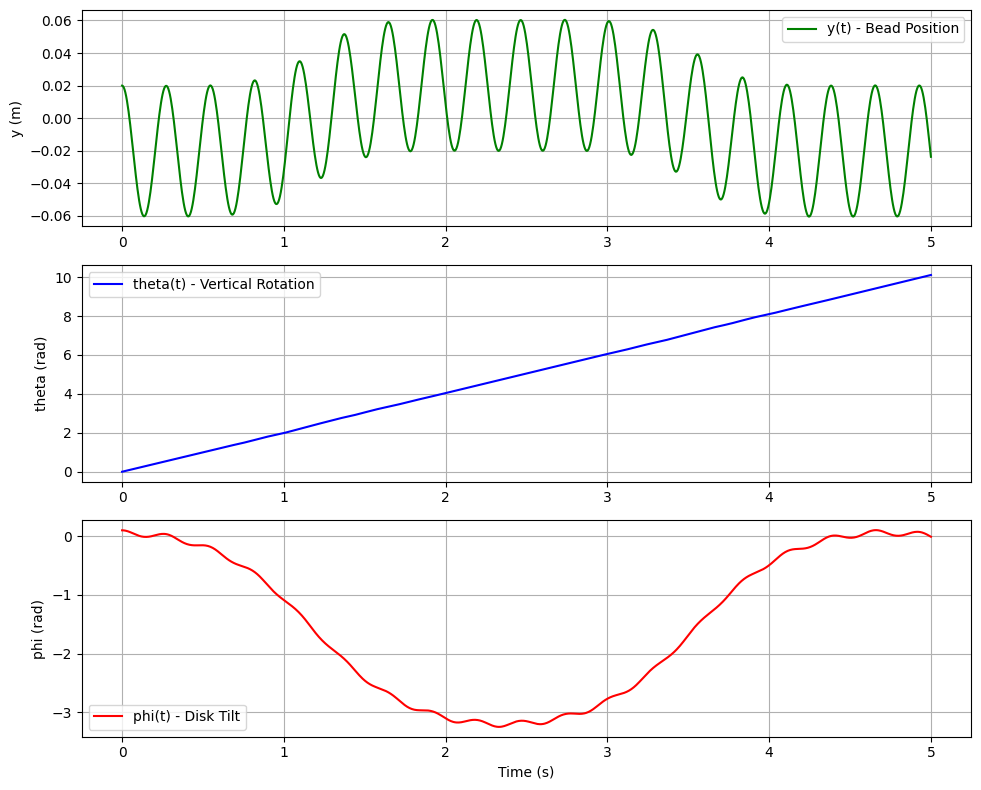

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. System Parameters
rho = 2710    # kg/m^3
r = 0.1       # m
h = 0.01      # m
d = 0.05      # m
b = 0.01      # m (half-width, given width is 2b)
l = 0.08      # m (half-length, given length is 2l)
g = 10        # m/s^2

# ASSUMED VALUES (Not provided in the problem description)
m = 0.1       # Mass of bead (kg)
k = 50.0      # Spring constant (N/m)

# 2. Derive Inertia Properties
# Solid disk
M_solid = rho * np.pi * r**2 * h
I11_solid = 0.5 * M_solid * r**2
I22_solid = M_solid * (r**2 / 4 + h**2 / 12)
I33_solid = I22_solid

# Slot (Removed material)
M_slot = 4 * rho * l * b * h
M_s = M_slot
# Slot inertia at its own CM
I11_slot_cm = M_slot * (b**2 + l**2) / 3
I22_slot_cm = M_slot * (l**2 + h**2 / 4) / 3
I33_slot_cm = M_slot * (b**2 + h**2 / 4) / 3
# Shift slot inertia to origin O using parallel axis theorem
I11_slot_O = I11_slot_cm + M_slot * d**2
I33_slot_O = I33_slot_cm + M_slot * d**2
I22_slot_O = I22_slot_cm  # No shift along c2 relative to c2 axis

# Final Disk Inertia Tensor at O (Subtract slot from solid disk)
I11 = I11_solid - I11_slot_O
I22 = I22_solid - I22_slot_O
I33 = I33_solid - I33_slot_O

# 3. Define Equations of Motion
def equations(t, Y):
    theta, phi, y, w_theta, w_phi, v_y = Y
    sin_phi = np.sin(phi)
    cos_phi = np.cos(phi)

    # Effective Theta inertia and its derivative
    M11 = I22 * sin_phi**2 + I33 * cos_phi**2 + m * (y * sin_phi + d * cos_phi)**2
    M11_dot = 2 * (I22 - I33) * sin_phi * cos_phi * w_phi + \
              2 * m * (y * sin_phi + d * cos_phi) * (v_y * sin_phi + y * w_phi * cos_phi - d * w_phi * sin_phi)

    alpha_theta = -(M11_dot * w_theta) / M11 if M11 != 0 else 0

    # Forcing terms for phi and y
    F_phi = -2 * m * y * v_y * w_phi + \
            (I22 - I33) * sin_phi * cos_phi * w_theta**2 + \
            m * (y * sin_phi + d * cos_phi) * (y * cos_phi - d * sin_phi) * w_theta**2 - \
            m * g * (y * sin_phi + d * cos_phi) + M_s * g * d * cos_phi

    F_y = m * w_theta**2 * (y * sin_phi + d * cos_phi) * sin_phi + \
          m * y * w_phi**2 - m * g * cos_phi - k * y

    # Invert the 2x2 mass matrix for phi and y accelerations
    det = m * I11 + m**2 * y**2
    alpha_phi = (F_phi + d * F_y) / (I11 + m * y**2)
    a_y = (m * d * F_phi + (I11 + m * y**2 + m * d**2) * F_y) / det

    return [w_theta, w_phi, v_y, alpha_theta, alpha_phi, a_y]

# 4. Run Simulation
# Initial Conditions: [theta, phi, y, w_theta, w_phi, v_y]
Y0 = [0.0, 0.1, 0.02, 2.0, 0.0, 0.0]
t_span = (0, 5)
t_eval = np.linspace(0, 5, 1000)

sol = solve_ivp(equations, t_span, Y0, t_eval=t_eval, method='RK45')

# 5. Plotting
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(sol.t, sol.y[2], 'g', label='y(t) - Bead Position')
plt.ylabel('y (m)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(sol.t, sol.y[0], 'b', label='theta(t) - Vertical Rotation')
plt.ylabel('theta (rad)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(sol.t, sol.y[1], 'r', label='phi(t) - Disk Tilt')
plt.ylabel('phi (rad)')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
